In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../../../../dataset/nf_uq_balanced_dataset.parquet"
raw_data = pd.read_parquet(DATA_PATH)
df = raw_data.copy()
pd.set_option('display.max_columns', None)
df


,L4_SRC_PORT,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label,Dataset
0,19094,80,6,7.000,420,3,0,0,2,2,0,4293024,1943,0,64,64,140,140,0,140,140280.0,0.0,140,1,0,0,1120000,0,0,3,0,0,0,512,0,35840,140,0,0,0,0.0,DoS,NaN
1,33720,80,6,7.000,140,1,0,0,2,2,0,0,0,0,0,0,140,140,0,140,140.0,0.0,0,0,0,0,1120000,0,0,1,0,0,0,512,0,0,0,0,0,0,0.0,DoS,NaN
2,62243,53,17,0.000,68,1,84,1,0,0,0,0,0,0,0,0,84,68,68,84,68.0,84.0,0,0,0,0,544000,672000,2,0,0,0,0,0,0,0,0,40768,1,20,0.0,Benign,NaN
3,50028,3389,6,0.000,1476,8,1873,7,222,222,90,0,0,0,96,96,1213,40,40,1213,1476.0,1873.0,0,0,0,0,11808000,14984000,10,2,1,1,1,8192,64000,0,0,0,0,0,0.0,Benign,NaN
4,42056,21,6,1.000,840,14,560,14,22,2,20,4294701,266,266,63,63,60,40,40,60,840.0,560.0,0,0,0,0,24000,16000,28,0,0,0,0,26883,0,0,0,0,0,0,0.0,Brute Force,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1240337,21676,21,6,1.000,2059,37,2816,39,24,24,24,4294952,15,15,31,32,106,52,52,106,2506.0,3058.0,505,8,887,10,808000,944000,87,0,0,0,0,21720,18824,63744,249,0,0,0,125.0,Benign,NaN
1240338,57089,53,17,5.126,63,1,79,1,0,0,0,0,0,0,0,0,79,63,63,79,63.0,79.0,0,0,0,0,504000,632000,2,0,0,0,0,0,0,0,0,23827,1,60,0.0,Benign,NaN
1240339,59600,53,17,0.000,74,1,90,1,0,0,0,0,0,0,0,0,90,74,74,90,74.0,90.0,0,0,0,0,592000,720000,2,0,0,0,0,0,0,0,0,30933,1,60,0.0,Benign,NaN
1240340,23461,80,6,7.000,280,2,0,0,2,2,0,4292920,2047,0,64,64,140,140,0,140,140140.0,0.0,140,1,0,0,1120000,0,0,2,0,0,0,512,0,35840,140,0,0,0,0.0,DoS,NaN


Label
Benign           400000
DDoS             300000
DoS              299999
Brute Force      123982
Infilteration    116361
Name: count, dtype: Int64

% distribution:
Label
Benign           32.25
DDoS             24.19
DoS              24.19
Brute Force       10.0
Infilteration     9.38
Name: count, dtype: Float64


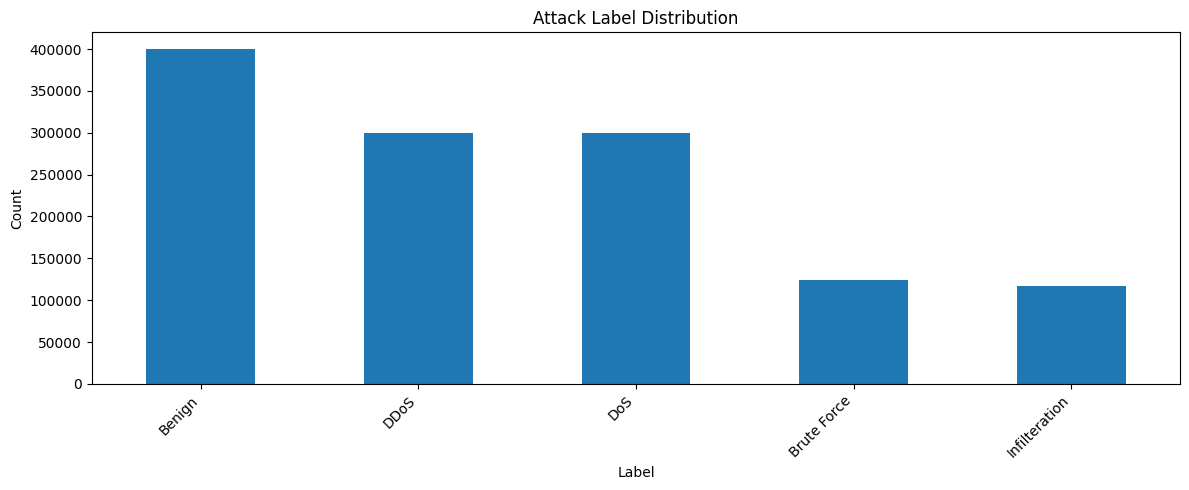

In [2]:
# ── Label distribution ──────────────────────────────────────────────────────
label_counts = df['Label'].value_counts()
print(label_counts)
print(f"\n% distribution:\n{(label_counts / len(df) * 100).round(2)}")

plt.figure(figsize=(12, 5))
label_counts.plot(kind='bar')
plt.title('Attack Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [3]:

# ── Group similar attack types ───────────────────────────────────────────────
attack_group_mapping = {
    # # BENIGN
    'Benign': 'BENIGN',
    'DDoS': 'DDoS',
    'DoS': 'DoS',
    'Brute Force': 'Brute Force',
    'Infilteration': 'Infiltration',
}

# Apply mapping; rows with unmapped labels are dropped
df['Label'] = df['Label'].map(attack_group_mapping)
df.dropna(subset=['Label'], inplace=True)

print(f"Groups after mapping : {df['Label'].nunique()}")
for g, cnt in df['Label'].value_counts().items():
    print(f"  {g:<20} {cnt:>10,}  ({cnt/len(df)*100:.2f}%)")


Groups after mapping : 5
  BENIGN                  400,000  (32.25%)
  DDoS                    300,000  (24.19%)
  DoS                     299,999  (24.19%)
  Brute Force             123,982  (10.00%)
  Infiltration            116,361  (9.38%)


In [4]:
# ── Check missing / infinity values ─────────────────────────────────────────
missing = df.isnull().sum()
print("MISSING VALUES\n", missing[missing > 0])

numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = {col: np.isinf(df[col]).sum()
              for col in numeric_cols if np.isinf(df[col]).sum() > 0}
print("\nINFINITY VALUES")
print(inf_counts if inf_counts else "None")


MISSING VALUES
 Dataset    1240342
dtype: int64

INFINITY VALUES
{'SRC_TO_DST_SECOND_BYTES': np.int64(3)}


In [5]:
# ── Handle inf → NaN → fill with median ─────────────────────────────────────
df_processed = df.copy()
df_processed.replace([np.inf, -np.inf], np.nan, inplace=True)

numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)

print(f"NaN remaining : {df_processed.isnull().sum().sum()}")
print(f"Shape         : {df_processed.shape}")


NaN remaining : 1240342
Shape         : (1240342, 43)


/tmp/ipykernel_235980/2204114694.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(df_processed[col].median(), inplace=True)
/home/huyho/.local/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/tmp/ipykernel_235980/2204114694.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pand

In [6]:
# ── Drop identifier / metadata columns ──────────────────────────────────────
keywords = ['flow id', 'flow_id', 'source ip', 'destination ip',
            'src ip', 'dst ip', 'timestamp', 'source port', 'dst port']
cols_to_drop = [c for c in df_processed.columns
                if any(k in c.lower() for k in keywords)]

df_processed.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"Dropped : {cols_to_drop}")
print(f"Shape   : {df_processed.shape}")


Dropped : []
Shape   : (1240342, 43)


In [7]:
# ── Remove low-variance features ─────────────────────────────────────────────
from sklearn.feature_selection import VarianceThreshold

y = df_processed['Label']
X = df_processed.drop('Label', axis=1)

selector = VarianceThreshold(threshold=0.01)
X_hv = selector.fit_transform(X)
selected_features = X.columns[selector.get_support()].tolist()

df_processed = pd.DataFrame(X_hv, columns=selected_features)
df_processed['Label'] = y.values

print(f"Features : {X.shape[1]} → {len(selected_features)} (removed {X.shape[1]-len(selected_features)})")
print(f"Shape    : {df_processed.shape}")


Features : 42 → 41 (removed 1)
Shape    : (1240342, 42)


/home/huyho/.local/lib/python3.10/site-packages/sklearn/feature_selection/_variance_threshold.py:114: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)


In [8]:
# ── Remove outliers via Z-score (threshold = 3) ──────────────────────────────
from scipy import stats

X_temp = df_processed.drop('Label', axis=1)
y_temp = df_processed['Label']

mask = (np.abs(stats.zscore(X_temp)) < 3).all(axis=1)
df_processed = X_temp[mask].copy()
df_processed['Label'] = y_temp[mask]

print(f"Removed  : {(~mask).sum()} outliers ({(~mask).mean()*100:.2f}%)")
print(f"Shape    : {df_processed.shape}")


Removed  : 264230 outliers (21.30%)
Shape    : (976112, 42)


In [9]:
# ── Drop highly correlated features (r > 0.95) ───────────────────────────────
X_for_corr = df_processed.drop('Label', axis=1)
upper = X_for_corr.corr().abs().where(
    np.triu(np.ones(X_for_corr.shape[1], dtype=bool), k=1))
to_drop = [c for c in upper.columns if upper[c].max() > 0.95]

df_processed.drop(columns=to_drop, inplace=True)
print(f"Dropped  : {len(to_drop)} correlated features")
print(f"Shape    : {df_processed.shape}")


Dropped  : 4 correlated features
Shape    : (976112, 38)


In [10]:
# ── Label encoding ───────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
import pickle

le = LabelEncoder()
df_processed['Label_Encoded'] = le.fit_transform(df_processed['Label'])

for idx, label in enumerate(le.classes_):
    print(f"{idx}: {label}  ({(df_processed['Label_Encoded']==idx).sum()} samples)")


0: BENIGN  (220715 samples)
1: Brute Force  (106797 samples)
2: DDoS  (280359 samples)
3: DoS  (294052 samples)
4: Infiltration  (74189 samples)


In [11]:
# ── Train / test split (stratified 80/20) ────────────────────────────────────
from sklearn.model_selection import train_test_split

X = df_processed.drop(['Label', 'Label_Encoded'], axis=1)
y = df_processed['Label_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")


Train : (780889, 37)  |  Test : (195223, 37)


In [12]:
# ── Feature scaling (StandardScaler) ─────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)

with open('scaler.pkl1', 'wb') as f:
    pickle.dump(scaler, f)

print(f"Train scaled : {X_train_scaled.shape}  |  Test scaled : {X_test_scaled.shape}")


Train scaled : (780889, 37)  |  Test scaled : (195223, 37)


In [13]:
# ── Final feature summary ─────────────────────────────────────────────────────
print(f"Features : {X_train_scaled.shape[1]}  |  Classes : {len(le.classes_)}")
print(f"Train    : {X_train_scaled.shape[0]:,} samples")
print(f"Test     : {X_test_scaled.shape[0]:,} samples")
for i, c in enumerate(X_train_scaled.columns, 1):
    print(f"  {i:3d}. {c}")


Features : 37  |  Classes : 5
Train    : 780,889 samples
Test     : 195,223 samples
    1. L4_SRC_PORT
    2. L4_DST_PORT
    3. PROTOCOL
    4. L7_PROTO
    5. IN_BYTES
    6. IN_PKTS
    7. OUT_BYTES
    8. OUT_PKTS
    9. TCP_FLAGS
   10. CLIENT_TCP_FLAGS
   11. SERVER_TCP_FLAGS
   12. FLOW_DURATION_MILLISECONDS
   13. DURATION_IN
   14. DURATION_OUT
   15. MIN_TTL
   16. LONGEST_FLOW_PKT
   17. SHORTEST_FLOW_PKT
   18. MIN_IP_PKT_LEN
   19. SRC_TO_DST_SECOND_BYTES
   20. DST_TO_SRC_SECOND_BYTES
   21. RETRANSMITTED_IN_BYTES
   22. RETRANSMITTED_IN_PKTS
   23. RETRANSMITTED_OUT_BYTES
   24. RETRANSMITTED_OUT_PKTS
   25. SRC_TO_DST_AVG_THROUGHPUT
   26. DST_TO_SRC_AVG_THROUGHPUT
   27. NUM_PKTS_UP_TO_128_BYTES
   28. NUM_PKTS_128_TO_256_BYTES
   29. NUM_PKTS_256_TO_512_BYTES
   30. NUM_PKTS_512_TO_1024_BYTES
   31. TCP_WIN_MAX_IN
   32. TCP_WIN_MAX_OUT
   33. ICMP_TYPE
   34. DNS_QUERY_ID
   35. DNS_QUERY_TYPE
   36. DNS_TTL_ANSWER
   37. FTP_COMMAND_RET_CODE


In [14]:
# # IMPORTS model evaluation
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                            accuracy_score, precision_recall_fscore_support)
import seaborn as sns


In [15]:
SGD_classifier = SGDClassifier(
    alpha=0.0001, 
    eta0=0.1, 
    learning_rate='adaptive', 
    loss='modified_huber', 
    max_iter=1000, 
    penalty='elasticnet'
)

SGD_classifier.fit(X_train_scaled, y_train)


,loss,'modified_huber'
,penalty,'elasticnet'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [16]:
# ── Evaluate on train / test set ──────────────────────────────────────────────
y_train_pred = SGD_classifier.predict(X_train_scaled)
y_test_pred  = SGD_classifier.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)

print(f"Train accuracy : {train_acc*100:.2f}%")
print(f"Test  accuracy : {test_acc*100:.2f}%")
print(f"Gap            : {(train_acc - test_acc)*100:.2f}%  {'(overfitting)' if train_acc-test_acc>0.05 else '(OK)'}")


Train accuracy : 90.65%
Test  accuracy : 90.69%
Gap            : -0.04%  (OK)


In [17]:
# ── Classification report ─────────────────────────────────────────────────────
print(classification_report(y_test, y_test_pred, target_names=le.classes_, digits=4, zero_division=0))


              precision    recall  f1-score   support

      BENIGN     0.7349    0.9614    0.8330     44143
 Brute Force     0.9960    0.9991    0.9976     21359
        DDoS     0.9859    0.9871    0.9865     56072
         DoS     0.9826    0.9649    0.9737     58811
Infiltration     0.5447    0.0792    0.1383     14838

    accuracy                         0.9069    195223
   macro avg     0.8488    0.7983    0.7858    195223
weighted avg     0.8957    0.9069    0.8847    195223



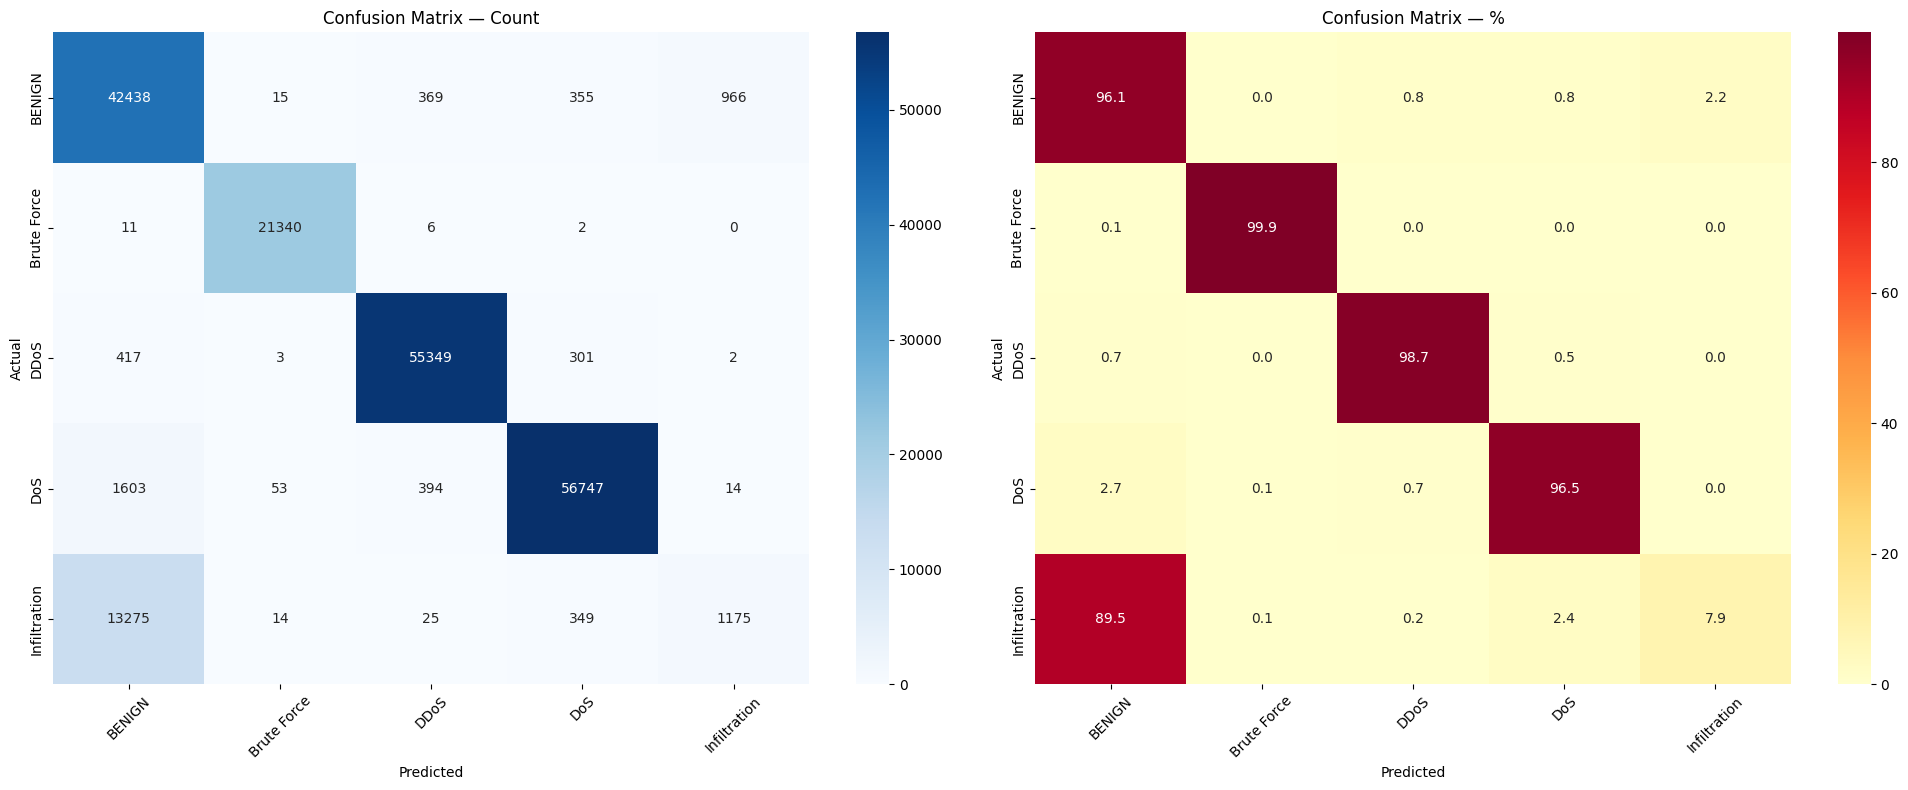

In [18]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_test_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax1)
ax1.set_title('Confusion Matrix — Count')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
ax1.tick_params(axis='x', rotation=45)

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax2)
ax2.set_title('Confusion Matrix — %')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
